## Indicate Dynawo and Modelica package.mo

In [ ]:
#=  The env variable DYNAWO_PATH must has be set beforehands to the root of the dynawo code.
    In case you are only working with the library distribution, the second part of the expression must be slightly modified.
    Anyway the package_file should be pointing to the package.mo file of the Dynawo library you want to use
=#

# Ruta de la librería Dynawo
ENV["DYNAWO_PATH"] = "/.../dynawo/ddb/Dynawo"
Dynawo_package_file = string(ENV["DYNAWO_PATH"], "/package.mo")

# Ruta de la librería Modelica (ajusta según tu instalación)
ENV["MODELICA_PATH"] = "/.../dynawo/OpenModelica/lib/omlibrary/Modelica"
Modelica_package_file = string(ENV["MODELICA_PATH"], "/package.mo")

## Import packages and data

In [2]:
using OMJulia
using Plots, DataFrames, CSV

In [ ]:
BESS = OMJulia.OMCSession()
ModelicaSystem(BESS,Dynawo_package_file,"Dynawo.Examples.BESS.WECC.BESScbCurrentSource",[Modelica_package_file])

StaticBESS = OMJulia.OMCSession()
ModelicaSystem(StaticBESS,Dynawo_package_file,"Dynawo.Examples.BESS.WECC.StaticBESS",[Modelica_package_file])

## Run initial simulation

We are using the model Dynawo.Examples.BESS.WECC.BESScbCurrentSource from the v1.7.0 Dynawo Modelica library. This model has been initialized elsewhere and already includes the right initialization parameters. The BESS.INIT model is not explicitly used in the model, contrary to what happens in Dynawo.Examples.BESS.WECC.BESSCurrentSource from Dynawo's master release.

We check that we can load the model, run a simulation with OMJulia and plot some results.

In [4]:
resultfile_name = string("BESS_base", ".csv")
simulate(BESS,resultfile = resultfile_name,
                simflags = "-override=outputFormat=csv")
resultfile = joinpath(getWorkDirectory(BESS), resultfile_name)
df = DataFrame(CSV.File(resultfile));

WebIO._IJuliaInit()

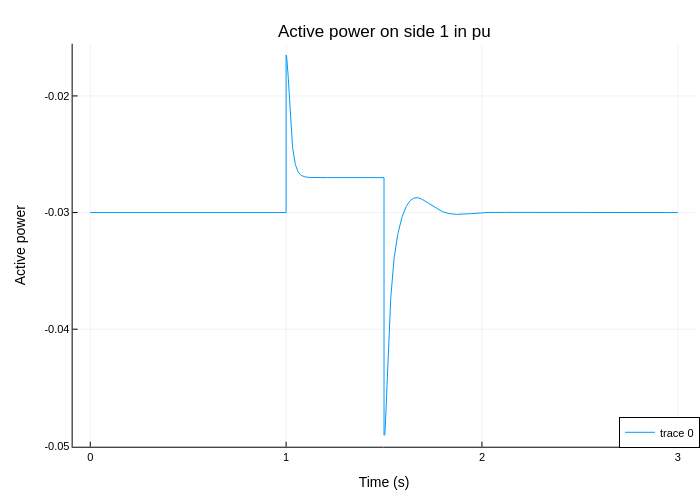

In [5]:
plotlyjs()
p2 = plot(df[!, "time"], df[!, "line.P1Pu"], label=["P1Pu"])
plot!(p2, legend=:bottomright, titlefontsize=12, labelfontsize=10)
title!(p2, "Active power on side 1 in pu")
xlabel!(p2, "Time (s)")
ylabel!(p2, "Active power")  

## Initialization with a static model

We want to automatise the initialization by using a companion model that solves an initial power flow and also runs the INIT model por the internal BESS parameters.

In the static model (Dynawo.Examples.BESS.WECC.StaticBESS), we replace the BESS WECC by a simplified generator with fixed PV and remove the fault in the infinite bus. We also include the BESS_INIT and the initial algorithm.

The network is simple enough that the initial power flow is not necessary in order to initialise the BESS_INIT model, which only requires the initial values of voltage and power.

The procedure is the following: first we simulate the static model, which runs the BESS_INIT and gives us a series of variables as a result. After that, we extract the variables and set them as initial parameters for the BESS in the dynamic model.

In [13]:
simulate(StaticBESS)
(Id0Pu, Iq0Pu, PF0, PInj0Pu, QInj0Pu, UInj0Pu, i0Pu_re, i0Pu_im, iInj0Pu_re, iInj0Pu_im, u0Pu_re, u0Pu_im, uInj0Pu_re, uInj0Pu_im) = getContinuous(StaticBESS, ["bess_INIT.Id0Pu","bess_INIT.Iq0Pu","bess_INIT.PF0","bess_INIT.PInj0Pu","bess_INIT.QInj0Pu","bess_INIT.UInj0Pu","bess_INIT.i0Pu.re","bess_INIT.i0Pu.im","bess_INIT.iInj0Pu.re","bess_INIT.iInj0Pu.im","bess_INIT.u0Pu.re","bess_INIT.u0Pu.im","bess_INIT.uInj0Pu.re","bess_INIT.uInj0Pu.im"]);

In [16]:
setParameters(BESS, [
    "BESScb.Id0Pu = " * string(Id0Pu),
    "BESScb.Iq0Pu = " * string(Iq0Pu),
    "BESScb.PF0 = " * string(PF0),
    "BESScb.PInj0Pu = " * string(PInj0Pu),
    "BESScb.QInj0Pu = " * string(QInj0Pu),
    "BESScb.UInj0Pu = " * string(UInj0Pu),
    "BESScb.i0Pu.re = " * string(i0Pu_re),
    "BESScb.i0Pu.im = " * string(i0Pu_im),
    "BESScb.iInj0Pu.re = " * string(iInj0Pu_re),
    "BESScb.iInj0Pu.im = " * string(iInj0Pu_im),
    "BESScb.u0Pu.re = " * string(u0Pu_re),
    "BESScb.u0Pu.im = " * string(u0Pu_im),
    "BESScb.uInj0Pu.re = " * string(uInj0Pu_re),
    "BESScb.uInj0Pu.im = " * string(uInj0Pu_im),
    "BESScb.s0Pu.re = " * string(-0.03),
    "BESScb.s0Pu.im = " * string(0),
])

In [17]:
resultfile_name = string("BESS_modified", ".csv")
simulate(BESS,resultfile = resultfile_name,
                simflags = "-override=outputFormat=csv")
resultfile = joinpath(getWorkDirectory(BESS), resultfile_name)
df = DataFrame(CSV.File(resultfile));

BESScb.PF0=1.0

BESScb.iInj0Pu.im=7.231049999997479e-7

BESScb.i0Pu.im=-4.338629999998488e-8

BESScb.u0Pu.re=0.9999999999989543

BESScb.Iq0Pu=1.4999999999355264e-12

BESScb.uInj0Pu.re=0.9999999999989543

BESScb.uInj0Pu.im=1.446212999999496e-6

BESScb.i0Pu.re=-0.029999999999968628

BESScb.UInj0Pu=1.0

BESScb.s0Pu.im=0

BESScb.QInj0Pu=1.5000000000414055e-12

BESScb.Id0Pu=0.5

BESScb.PInj0Pu=0.5

BESScb.iInj0Pu.re=0.49999999999947714

BESScb.u0Pu.im=1.4462099999994959e-6

BESScb.s0Pu.re=-0.03



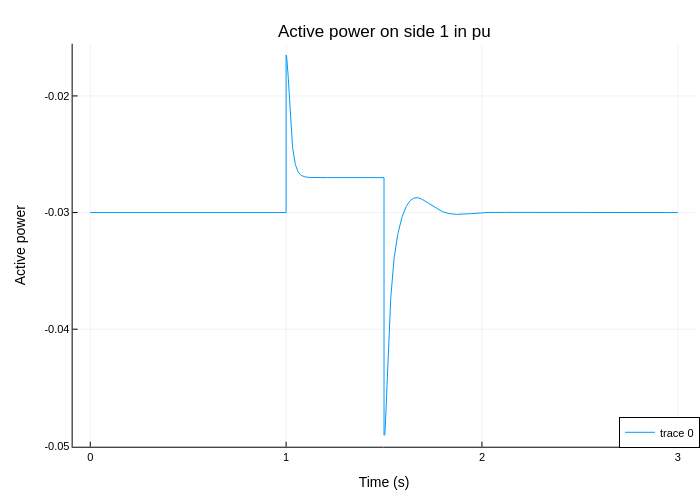

In [9]:
plotlyjs()
p2 = plot(df[!, "time"], df[!, "line.P1Pu"], label=["P1Pu"])
plot!(p2, legend=:bottomright, titlefontsize=12, labelfontsize=10)
title!(p2, "Active power on side 1 in pu")
xlabel!(p2, "Time (s)")
ylabel!(p2, "Active power")  